In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import math
import datetime
import collections
from collections import OrderedDict
from torch import nn
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from torch.utils.data import DataLoader
import random

In [2]:
df = pd.read_csv('../data/main_timestamp.csv')

In [3]:
def preprocess(df):
    # first convert everything to int
    for col in df.select_dtypes(include=['number']):
        df[col] = df[col].apply(lambda x: round(x))

    # Get day, month, year, time_start, time_end
    df['day'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).day)
    df['month'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).month)
    df['year'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).year)
    df['hour_start'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).hour)
    df['workout_window'] = df['hour_start'].apply(lambda x: 'morning' if x < 11 else 'afternoon' if x < 17 else 'evening')
preprocess(df)
df

,distance,duration,gender,heart_rate,sport,userId,timestamp_start,timestamp_end,calories,day,month,year,hour_start,workout_window
0,56,10810,male,143,bike,139383,1276037798,1276048608,3757,8,6,2010,15,afternoon
1,53,10798,male,138,bike,139383,1279234743,1279245541,3472,15,7,2010,15,afternoon
2,9,4838,male,159,run,212295,1274655206,1274660044,1054,23,5,2010,15,afternoon
3,6,2916,male,154,run,212295,1271032062,1271034978,620,11,4,2010,17,evening
4,26,6713,male,140,bike,139383,1288449864,1288456577,1530,30,10,2010,7,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166013,6,3688,male,160,bike,2934877,1444333665,1444337353,984,8,10,2015,12,afternoon
166014,3,1579,male,144,bike,2934877,1445364200,1445365779,358,20,10,2015,11,afternoon
166015,8,9931,male,156,bike,2934877,1445752071,1445762002,1623,24,10,2015,22,evening
166016,34,7072,male,146,bike,1731481,1440629051,1440636123,1581,26,8,2015,15,afternoon


In [4]:
all_sports = set(df['sport'].unique())
k = 1

df_labels = pd.DataFrame()

for userId in df['userId'].unique():
    subset = df[df['userId'] == userId].copy()

    # Positive samples
    subset.loc[:, 'label'] = 1

    # Negative samples
    subset_negative = subset.copy()
    subset_negative.loc[:, 'label'] = 0

    # Make 3 copy and append into the same dataframe
    new_df = subset

    # Workout activities that the user hasn't tried
    new_activities = list(all_sports - set(subset.sport.unique()))

    for i in range(k):
        negative_df = subset_negative.copy()
        negative_df = subset_negative.sample(frac=1)
        negative_df['sport'] = negative_df.apply(lambda x: random.choice(new_activities), axis=1)
        new_df = pd.concat([new_df, negative_df.copy()])


    df_labels = pd.concat([df_labels, new_df])

df = df_labels

In [5]:
id_encoder = OrdinalEncoder()
sport_encoder = OrdinalEncoder()

df[['userId']] = id_encoder.fit_transform(df[['userId']])
df[['sport']] = sport_encoder.fit_transform(df[['sport']])

df = df.reset_index(drop=True)

df

,distance,duration,gender,heart_rate,sport,userId,timestamp_start,timestamp_end,calories,day,month,year,hour_start,workout_window
0,56,10810,male,143,3.0,43.0,1276037798,1276048608,3757,8,6,2010,15,afternoon
1,53,10798,male,138,3.0,43.0,1279234743,1279245541,3472,15,7,2010,15,afternoon
2,9,4838,male,159,26.0,59.0,1274655206,1274660044,1054,23,5,2010,15,afternoon
3,6,2916,male,154,26.0,59.0,1271032062,1271034978,620,11,4,2010,17,evening
4,26,6713,male,140,3.0,43.0,1288449864,1288456577,1530,30,10,2010,7,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166013,6,3688,male,160,3.0,400.0,1444333665,1444337353,984,8,10,2015,12,afternoon
166014,3,1579,male,144,3.0,400.0,1445364200,1445365779,358,20,10,2015,11,afternoon
166015,8,9931,male,156,3.0,400.0,1445752071,1445762002,1623,24,10,2015,22,evening
166016,34,7072,male,146,3.0,254.0,1440629051,1440636123,1581,26,8,2015,15,afternoon


In [6]:
def train_test_split_chronological(df, test_size=0.2): 
    training_ids = []
    testing_ids = []

    training_size = 1 - test_size
    
    uids = df['userId'].unique()
    for userId in uids:
        subset = df[df['userId'] == userId]
        values = np.sort(df[df['userId'] == userId].timestamp_start.values)

        # if only one values, make it appear in both
        training_length = int(training_size * len(values))
        if training_length <= 1:
            trainset = values
            testset = values
        else:
            trainset = values[:training_length]
            testset = values[training_length:]
    
        training_ids.extend(subset[subset['timestamp_start'].isin(trainset)].index)
        testing_ids.extend(subset[subset['timestamp_start'].isin(testset)].index)

    train_df, test_df = df.iloc[training_ids], df.iloc[testing_ids]

    return train_df, test_df

In [7]:
class FitRecDataset():
    def __init__(self, dataframe):
        # Get an encoder
        self.df = dataframe

        self.df = self.df[['userId', 'sport']]
        
        self.features = torch.tensor(self.df.loc[:, ['userId']].values, dtype=int)
        self.labels = torch.tensor(self.df.loc[:, 'sport'].values, dtype=int)
            
    def __len__(self):
        return len(self.features)

    def get_encoder(self):
        return self.encoder

    def __getitem__(self, idx):
        """
        Return a row of data.
        """
        
        return self.features[idx], self.labels[idx]


In [8]:
train_df, test_df = train_test_split_chronological(df, test_size=0.2)
train_df.shape, test_df.shape

((132430, 14), (33651, 14))

In [9]:
train_df['userId'].unique()

array([ 43.,  59.,  83., ..., 110., 618., 781.])

In [10]:
trainset = FitRecDataset(train_df)
testset = FitRecDataset(test_df)

In [11]:
len(trainset), len(testset)

(132430, 33651)

In [12]:
# batch training and testing data
train_dataloader = DataLoader(trainset, batch_size=128, shuffle=True, drop_last=True)
test_dataloader = DataLoader(testset, batch_size=128, shuffle=True, drop_last=True)

In [13]:
for features, labels in train_dataloader:
    print(features)
    print(labels)

    break

tensor([[ 208],
        [ 991],
        [ 133],
        [ 684],
        [ 396],
        [ 300],
        [ 916],
        [ 484],
        [  36],
        [ 770],
        [ 419],
        [ 696],
        [ 585],
        [ 516],
        [ 143],
        [ 418],
        [ 506],
        [ 143],
        [ 361],
        [  20],
        [ 985],
        [  30],
        [ 203],
        [ 592],
        [  66],
        [ 164],
        [ 668],
        [ 840],
        [1002],
        [ 131],
        [ 806],
        [ 593],
        [ 602],
        [ 140],
        [   7],
        [ 774],
        [1051],
        [ 917],
        [ 724],
        [ 724],
        [ 736],
        [ 668],
        [ 153],
        [  74],
        [ 592],
        [ 883],
        [  29],
        [ 482],
        [ 152],
        [ 521],
        [ 132],
        [  86],
        [ 416],
        [ 390],
        [ 558],
        [ 211],
        [  31],
        [  69],
        [ 248],
        [  60],
        [1021],
        [ 412],
        

Create features from the training dataframe, then use those features to predict the same user on testing time.

# User model

In [14]:
def get_per_sport_hr(subset):
    values = subset.groupby('sport', as_index=False).calories.mean().values
    per_sport_heart_rate = OrderedDict()
    
    for sport in df['sport'].unique():
        per_sport_heart_rate[sport] = 0
    
    for i in range(len(values)):
        sport, hr = values[i]
        per_sport_heart_rate[sport] = round(hr)
    
    return np.array(list(per_sport_heart_rate.values()))

In [15]:
def get_workout_frequency(subset):    
    # Workout frequency
    first_timestamp = subset.timestamp_start.min()
    last_timestamp = subset.timestamp_start.max()
    start = datetime.datetime.fromtimestamp(first_timestamp)
    end = datetime.datetime.fromtimestamp(last_timestamp)
    
    weeks = int((end - start).days / 7)

    if weeks == 0:
        return 1
    
    workout_per_week = len(subset) / weeks
    
    return round(workout_per_week)

def get_calories_per_week(subset):
     # Workout frequency
    first_timestamp = subset.timestamp_start.min()
    last_timestamp = subset.timestamp_start.max()
    start = datetime.datetime.fromtimestamp(first_timestamp)
    end = datetime.datetime.fromtimestamp(last_timestamp)
    
    weeks = int((end - start).days / 7)
    if weeks == 0:
        return 1
    
    workout_per_week = subset.calories.sum() / weeks
    
    return round(workout_per_week)

def get_duration_per_week(subset):
    # Workout frequency
    first_timestamp = subset.timestamp_start.min()
    last_timestamp = subset.timestamp_start.max()
    start = datetime.datetime.fromtimestamp(first_timestamp)
    end = datetime.datetime.fromtimestamp(last_timestamp)
    
    weeks = int((end - start).days / 7)
    if weeks == 0:
        return 1
    
    workout_per_week = subset.calories.sum() / weeks
    
    return round(workout_per_week)

In [28]:
def get_user_features(userId):
    subset = train_df[train_df['userId'] == userId].sort_values('timestamp_start')
    # How many workout per week
    workout_frequency = get_workout_frequency(subset)

    # Calories burn per week
    calories_per_week = get_calories_per_week(subset)

    # Workout duration per week
    duration_per_week = get_duration_per_week(subset)

    # Most common workout window -- either morning, afternoon or evening
    freq = collections.Counter(subset['workout_window'])
    common_workout_window = max(freq, key=freq.get)

    if common_workout_window == 'morning':
        common_workout_window = 1
    elif common_workout_window == 'afternoon':
        common_workout_window = 2
    else:
        common_workout_window = 1

    # workout heart rate per activity
    hr_per_activity = get_per_sport_hr(subset)
    
    result = torch.cat(
        (
            torch.tensor([
                workout_frequency, calories_per_week, common_workout_window, duration_per_week
            ]),
            torch.tensor(hr_per_activity)
        )
    )

    return  torch.tensor([
                workout_frequency, calories_per_week, common_workout_window, duration_per_week
            ])

In [29]:
# Pre build features for users
uids = train_df['userId'].unique()
user_features = {}

for userId in uids:
    user_features[userId] = get_user_features(userId)


In [32]:
class UserModel(nn.Module):
    def __init__(self, user_dim, output_dim, user_features):
        """
        A user is defined by
            userId
            gender
        """
        super().__init__()
        self.id_embedding = nn.Embedding(user_dim, output_dim)
        self.user_features = user_features
        self.projection = nn.Linear(64, 256)
        
    def forward(self, user_ids):
        # Transform into embedding dimension
        id_embeddings = self.id_embedding(user_ids)
        features = torch.stack(([user_features[int(i)] for i in user_ids]))

        # Concatenate features
        user_embedding = torch.cat((id_embeddings, features), dim=1)
        user_embedding = self.projection(user_embedding)
        return user_embedding

In [38]:
class RetrievalModel(nn.Module):
    def __init__(self, user_dim, embedding_dim, user_features, in_dim, out_dim):
        super().__init__()
        self.user_embedding = UserModel(user_dim, embedding_dim, user_features)
        self.norm = nn.BatchNorm1d(in_dim)
        self.fc1 = nn.Linear(in_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, out_dim)
        
        self.activation = nn.ReLU()

    def forward(self, user_ids):
        user_embds = self.user_embedding(user_ids)
        user_embds = self.norm(user_embds)
        x = self.activation(self.fc1(user_embds))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.fc4(x)

        return x
        

In [39]:
# Define model
user_dim = train_df['userId'].nunique()
embedding_dim = 60
model = RetrievalModel(user_dim, embedding_dim, user_features, in_dim=256, out_dim=len(sport_encoder.categories_[0]))

# Loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)


running_loss = 0
epochs = 11

# Train for 5 epochs
for epoch in range(1, epochs):
    model.train()
    epoch_loss = 0
    for i, (train_features, train_labels) in enumerate(train_dataloader):
        optimizer.zero_grad()
        
        outputs = model(train_features.squeeze())
    
        loss = loss_fn(outputs, train_labels)
        
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()

    correct = 0
    total = 0
    model.eval()
    for train_features, train_labels in train_dataloader:
        outputs = model(train_features.squeeze())
        preds = outputs.softmax(dim=1).argmax(dim=1)
        correct += (preds == train_labels).sum().item()
        total += len(preds)
    
    print(f'Epoch {epoch} -- Loss: {epoch_loss / len(train_dataloader):5} // Acc: {correct / total}')

Epoch 1 -- Loss: 0.880265984417622 // Acc: 0.7008432059961315
Epoch 2 -- Loss: 0.6698895274901068 // Acc: 0.7573289410058027
Epoch 3 -- Loss: 0.634415599144635 // Acc: 0.7770641924564797
Epoch 4 -- Loss: 0.6210436993918059 // Acc: 0.7911327369439072
Epoch 5 -- Loss: 0.6107105266886477 // Acc: 0.7755379593810445
Epoch 6 -- Loss: 0.6040297742046747 // Acc: 0.7879140473887815
Epoch 7 -- Loss: 0.5992689805980808 // Acc: 0.7887073863636364
Epoch 8 -- Loss: 0.5909588680218912 // Acc: 0.7799882132495164
Epoch 9 -- Loss: 0.5881428827803646 // Acc: 0.7917220744680851
Epoch 10 -- Loss: 0.5824499628011216 // Acc: 0.7915407398452611


Precision @ 1: 0.8210227272727273
Recall @ 1: 0.5595749158249151
Precision @ 2: 0.7140151515151515
Recall @ 2: 0.7666854557479552
Precision @ 3: 0.5760732323232346
Recall @ 3: 0.8336046476671469
Precision @ 4: 0.47821969696969696
Recall @ 4: 0.8741071428571425
Precision @ 5: 0.409280303030298
Recall @ 5: 0.899753863035113


Text(0.5, 0, 'Recall')

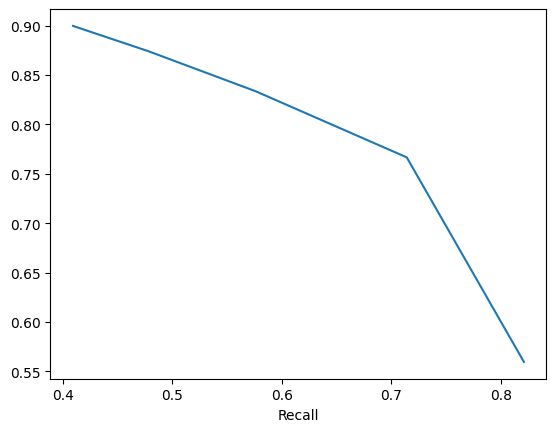

In [59]:
precisions = []
recalls = []
for k in range(1, 6):
    precision = 0
    recall = 0
    for user in train_df['userId'].unique():
        # K relevant items for users
        n_sports = train_df[train_df['userId'] == user]['sport'].unique()

        # All relevant items
        k_sports = n_sports[:k]
        
    
        # Prediction for this user 
        scores = model(torch.tensor([int(user)])).softmax(dim=1).detach().squeeze()
    
        # Pick K most probable items
        indices = np.argpartition(scores, -k)[-k:].numpy()

    
        # Sum up to later divide
        precision  += len(np.intersect1d(k_sports, indices)) / k
        recall += len(np.intersect1d(n_sports, indices)) / len(n_sports)

        
    precision_at_k = precision / train_df['userId'].nunique()
    recall_at_k = recall / train_df['userId'].nunique()
    print(f"Precision @ {k}: {precision_at_k}")
    print(f"Recall @ {k}: {recall_at_k}")
    precisions.append(precision_at_k)
    recalls.append(recall_at_k)

ax = sns.lineplot(x=precisions, y=recalls)
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Precision vs Recall @ K')

In [88]:
scores = model(torch.tensor([545])).softmax(dim=1).detach().squeeze()

indices = np.argpartition(scores, -5)[-5:]

print("Recommendation: ")
for sport in sport_encoder.inverse_transform(indices.reshape(-1, 1)):
    print('\t' + sport.item())

Recommendation: 
	kayaking
	circuit training
	bike
	rowing
	run


In [93]:
sport_encoder.inverse_transform(train_df[train_df['userId'] == 545].sport.unique().reshape(-1, 1))

array([['run'],
       ['kayaking'],
       ['bike']], dtype=object)

# Workout Profile

In [67]:
# 1. workout duration -- how long people use the thing?group by sport and average
# 2. workout avg calories -- how much calories burn per workout type
# 3. workout distance -- avg distance
# 4. workout heart rate -- avg heart rate
# 5. calories per minute -- group by sport, sum and then divide by 60?

workout_features = {}

def get_workout_features(workout_id):
    sport = workout_id

    avg_calories = round(train_df[train_df['sport'] == workout_id].calories.mean())
    avg_distance = round(train_df[train_df['sport'] == workout_id].distance.mean())
    avg_hr = round(train_df[train_df['sport'] == workout_id].heart_rate.mean())
    avg_duration = round(train_df[train_df['sport'] == workout_id].duration.mean())
    
    total_duration = train_df[train_df['sport'] == workout_id][['duration']].sum().item()
    total_calories_burn = train_df[train_df['sport'] == workout_id][['calories']].sum().item()
    calories_bpm = round(total_calories_burn / (total_duration / 60))

    result = torch.tensor([
                avg_calories, avg_distance, avg_hr, avg_duration # calories_bpm
            ])

    return result

for sport_id in train_df['sport'].unique():
    workout_features[sport_id] = get_workout_features(sport_id)

In [71]:
class WorkoutModel(nn.Module):
    def __init__(self, workout_dim, output_dim, workout_features):
        super().__init__()
        self.id_embedding = nn.Embedding(workout_dim, output_dim)
        self.workout_features = workout_features
        self.projection = nn.Linear(36, 128)

        
    def forward(self, workout_ids):
        # Transform into embedding dimension
        id_embeddings = self.id_embedding(workout_ids)
        features = torch.stack(([self.workout_features[int(i)] for i in workout_ids]))
        
        # Concatenate features
        workout_embedding = torch.cat((id_embeddings, features), dim=1)
        workout_embedding = self.projection(workout_embedding)
        return workout_embedding

In [88]:
class NeuralCF(nn.Module):
    def __init__(self, user_dim, embedding_dim, user_features, workout_dim, workout_features, in_dim, out_dim):
        super().__init__()
        self.user_embedding = UserModel(user_dim, embedding_dim, user_features)
        self.workout_embedding = WorkoutModel(workout_dim, embedding_dim, workout_features)
        self.norm1 = nn.BatchNorm1d(in_dim)
        self.norm2 = nn.BatchNorm1d(in_dim)

        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, out_dim)
        
        self.activation = nn.ReLU()

    def forward(self, user_ids, workout_ids):
        # Get user embeddings 
        user_embds = self.user_embedding(user_ids)
        user_embds = self.norm1(user_embds)

        # Get workout embeddings and project to match user embeddings
        workout_embds = self.workout_embedding(workout_ids)
        workout_embds = self.norm2(workout_embds)

        # Dot product
        x = user_embds @ workout_embds.T

       # print(x.shape)

        # Linear layers
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.fc4(x)

        return x
        

In [89]:
# Define model
user_dim = train_df['userId'].nunique() + 1
workout_dim = int(train_df['sport'].max()) + 1
embedding_dim=32
model = NeuralCF(user_dim, embedding_dim, user_features, workout_dim, workout_features, in_dim=128, out_dim=1)

# Loss function and optimizer
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


running_loss = 0
epochs = 10

# Train for 5 epochs
for epoch in range(1, epochs):
    model.train()
    epoch_loss = 0
    for i, (train_features, train_labels) in enumerate(train_dataloader):
        user_ids, workout_ids = train_features[:, 0], train_features[:, 1]
        optimizer.zero_grad()
    
        outputs = model(user_ids, workout_ids)
    
        loss = loss_fn(outputs.squeeze(), train_labels.float())
        
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()

    correct = 0
    total = 0
    model.eval()
    for train_features, train_labels in train_dataloader:
        user_ids, workout_ids = train_features[:, 0], train_features[:, 1]
        outputs = model(user_ids, workout_ids)
        preds = outputs.squeeze().sigmoid().round()
        correct += (preds == train_labels).sum().item()
        total += len(preds)
    
    print(f'Epoch {epoch} -- Loss: {epoch_loss / len(train_dataloader):5} // Acc: {correct / total}')

Epoch 1 -- Loss: 0.6935939434063003 // Acc: 0.499269578313253
Epoch 2 -- Loss: 0.6932115069067621 // Acc: 0.49986822289156624
Epoch 3 -- Loss: 0.6931999495230525 // Acc: 0.5000112951807228
Epoch 4 -- Loss: 0.6931887617743159 // Acc: 0.5000715361445783
Epoch 5 -- Loss: 0.6932347117274641 // Acc: 0.5000075301204819
Epoch 6 -- Loss: 0.693170320011047 // Acc: 0.49938253012048195
Epoch 7 -- Loss: 0.6932042039158832 // Acc: 0.5000075301204819
Epoch 8 -- Loss: 0.6931949750773878 // Acc: 0.5000112951807228
Epoch 9 -- Loss: 0.6931585427939174 // Acc: 0.4999698795180723


In [90]:
train_df['label'].sum() / len(train_df)

0.5

In [98]:
id_encoder.inverse_transform(torch.tensor([912]).reshape(1, -1))

array([[10719156]])

In [110]:
sport_ids = train_df[(train_df['userId'] == 912) & (train_df['label'] == 1)].sport.unique()
sport_ids

array([ 3., 39., 26.])

In [111]:
sport_encoder.inverse_transform(sport_ids.reshape(-1, 1))

array([['bike'],
       ['walk'],
       ['run']], dtype=object)